# Argentine Senate floor speech, 2000–2024

Analysis of the ar_congress corpus: 559 stenographic session transcripts
(versiones taquigráficas) published by the Senado de la Nación, parsed into
speaker-attributed speech turns and typed stenographer events (parser
0.4.18), with speakers resolved to persons. Provenance and terms:
[SOURCES.md](../SOURCES.md).

In [1]:
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
BLOCKS = ROOT / "data" / "processed" / "senado" / "blocks"

corpus = pd.concat([pd.read_parquet(p) for p in sorted(BLOCKS.glob("*.parquet"))], ignore_index=True)
speakers = pd.read_parquet(ROOT / "data" / "processed" / "senado" / "speakers.parquet")

speech = corpus[corpus.type == "speech"].merge(
    speakers[["session_id", "speaker_raw", "person_id", "person_name", "elected_ticket", "province", "match_status"]],
    on=["session_id", "speaker_raw"], how="left",
)
speech["words"] = speech.text.str.split().str.len()
speech["year"] = speech.session_date.str[:4].astype(int)
corpus["year"] = corpus.session_date.str[:4].astype(int)

# The portal lists these years but no longer serves most of the files, so
# their totals are a floor on what was said, not a measurement of it.
PARTIAL_YEARS = range(2000, 2004)

print(f"{corpus.session_id.nunique()} sessions | {len(corpus):,} rows | "
      f"{len(speech):,} speech turns | {speech.words.sum():,} words spoken")

/var/folders/ht/hrj3dkvj36g0wrcz5phcdv580000gn/T/ipykernel_3410/1166088179.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corpus = pd.concat([pd.read_parquet(p) for p in sorted(BLOCKS.glob("*.parquet"))], ignore_index=True)


558 sessions | 233,408 rows | 151,761 speech turns | 18,404,492 words spoken


## Sampling frame — read this before trusting any trend

The corpus is **not** a neutral sample of Senate activity, and two of the
distortions are large enough to invent trends on their own:

- **2000–2003 is thin, and not because the chamber was quiet.** The portal
  lists those sittings but no longer serves most of the files: 3 of 75
  sessions held for 2000, 10 of 83 for 2001, 4 of 47 for 2002, 34 of 47 for
  2003. From 2004 on, every session the portal lists is held. Any per-year
  total before 2004 is a floor, not a measurement — the charts below mark
  those years and the rate chart drops them.
- **Session counts swing with the political calendar**, from 46 sittings in
  2005 to 12 in the 2023 election year, so a fall in yearly word totals can
  mean fewer sittings rather than less speech. Both are shown separately.
- **Asambleas Legislativas are not Senate debate** — they are joint sittings
  where the President of the Nation speaks. They stay in the corpus but are
  excluded from every floor-speech figure here.
- **Alliance ≠ caucus.** The roster records the *electoral alliance* each
  senator was elected under, not the bloc they sat with. The two diverge
  sharply after 2015: radicals elected on Cambiemos and Juntos por el Cambio
  tickets appear under those labels and not under the UCR, which is why the
  groupings below put the UCR and the coalitions built around it together.

In [2]:
overview = (corpus.groupby(["year", "session_type"]).session_id.nunique()
            .unstack(fill_value=0))
overview["total"] = overview.sum(axis=1)
overview

session_type,ASAMBLEA,EN MINORÍA,ESPECIAL,ESPECIAL EN MINORÍA,ESPECIAL EXTRAORDINARIA,EXTRAORDINARIA,INFORMATIVA ESPECIAL,ORDINARIA,ORDINARIA CONTINUACIÓN,PREPARATORIA,REUNIÓN CONJ.AMBAS CÁMARAS,TRIBUNAL DE JUICIO POLITICO,total
year,,,,,,,,,,,,,
2000,1,0,1,0,0,0,0,0,0,1,0,0,3
2001,0,3,0,0,0,0,0,6,0,1,0,0,10
2002,0,3,1,0,0,0,0,0,0,0,0,0,4
2003,4,0,2,0,0,0,0,16,0,0,0,12,34
2004,2,1,3,0,0,1,0,30,0,1,0,2,40
2005,1,0,2,0,0,5,0,24,0,1,0,13,46
2006,2,0,2,0,0,2,0,29,0,1,0,0,36
2007,3,0,1,0,0,1,0,20,0,1,0,0,26
2008,3,0,0,0,0,2,1,22,0,1,0,0,29


## Who holds the floor?

**Floor speech** here means: speech turns by senators speaking from the
floor (`match_status == "matched_senator"`), outside Asambleas. Chair and
officer speech is excluded as procedural — the presiding officer's "Tiene
la palabra..." traffic would otherwise swamp every signal.

Alliances are grouped into four **party families** by the keyword rules in
the next cell — auditable and deliberately coarse, so that one bucket can
hold a party and the coalitions it later ran inside. Provincial alliances
(Movimiento Popular Neuquino, Cruzada Renovadora de San Juan, Juntos Somos
Río Negro, ...) stay in their own bucket even where their senators caucus
with a national bloc.

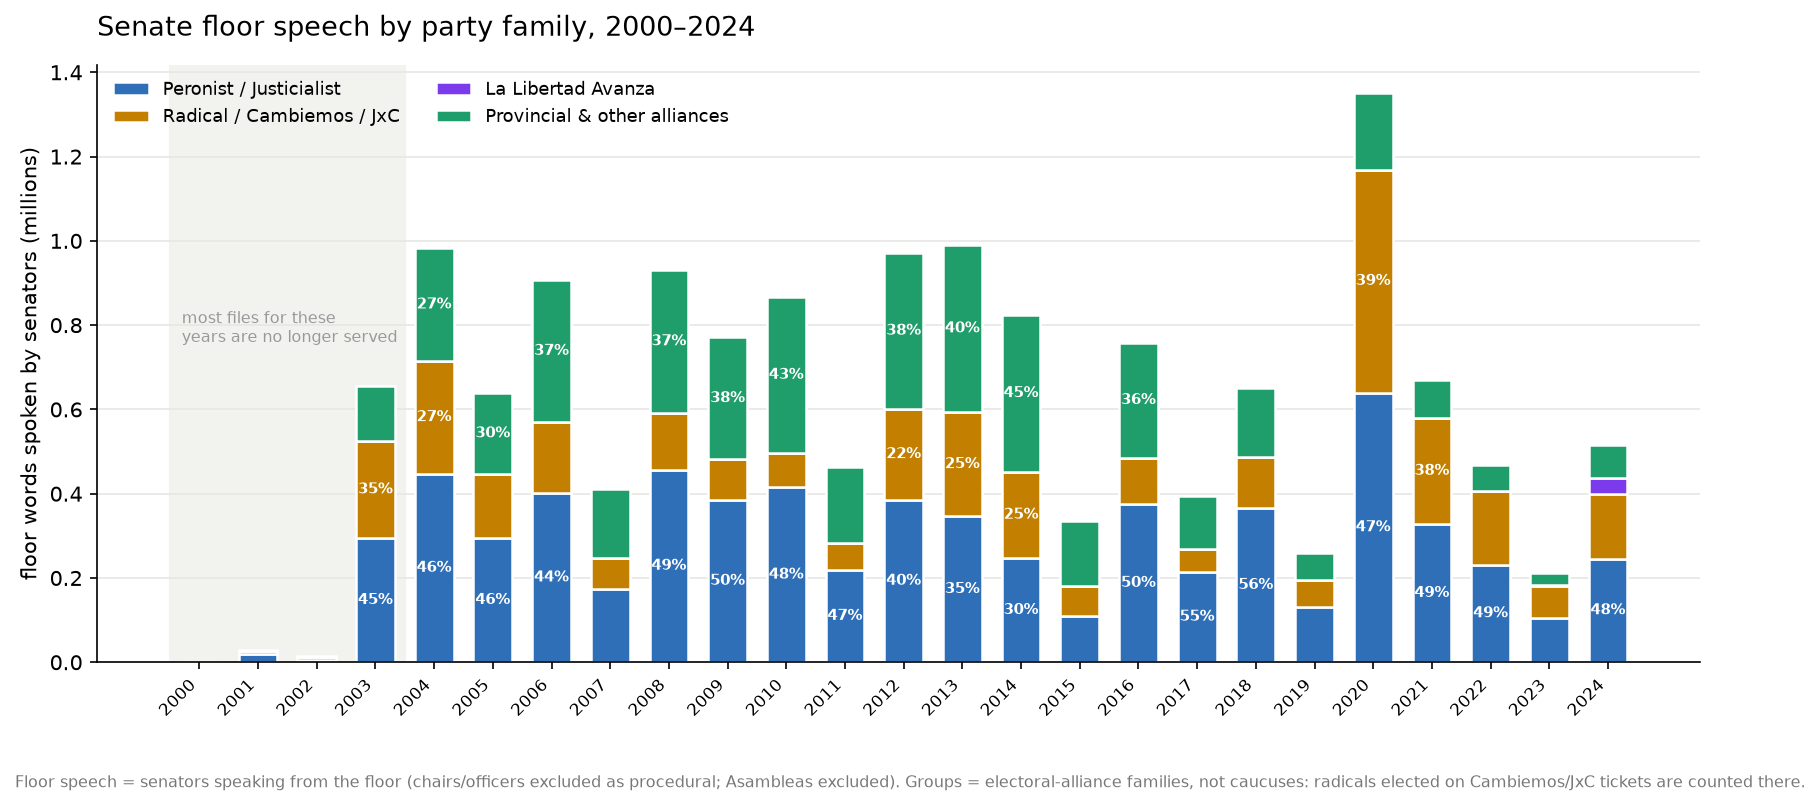

family,Peronist / Justicialist,Radical / Cambiemos / JxC,La Libertad Avanza,Provincial & other alliances
year,,,,
2000,0.001,0.000,0.000,0.000
2001,0.019,0.008,0.000,0.003
2002,0.005,0.007,0.000,0.003
2003,0.294,0.231,0.000,0.132
2004,0.447,0.268,0.000,0.267
2005,0.295,0.152,0.000,0.193
2006,0.402,0.168,0.000,0.338
2007,0.174,0.073,0.000,0.165
2008,0.457,0.134,0.000,0.340


In [3]:
def deaccent(s):
    return "".join(c for c in unicodedata.normalize("NFD", s) if not unicodedata.combining(c))

def family(alliance):
    """Group an electoral-alliance label into a party family.

    Order matters: the era-specific coalition labels are tested first, so a
    radical elected on a Cambiemos ticket lands with Cambiemos — which is
    what the ballot said — rather than with the UCR.
    """
    a = deaccent(str(alliance or "")).upper()
    if "LIBERTAD AVANZA" in a:
        return "La Libertad Avanza"
    if "CAMBIEMOS" in a or "JUNTOS POR EL CAMBIO" in a or "CIVICA RADICAL" in a or "UCR" in a:
        return "Radical / Cambiemos / JxC"
    if any(k in a for k in ("JUSTICIALIS", "PERONIS", "PARA LA VICTORIA", "DE LA VICTORIA",
                            "P/VICTORIA", "DE TODOS", "UNIDAD CIUDADANA", "UNION POR LA PATRIA")):
        return "Peronist / Justicialist"
    return "Provincial & other alliances"

floor = speech[(speech.match_status == "matched_senator") & (speech.session_type != "ASAMBLEA")].copy()
floor["family"] = floor.elected_ticket.map(family)

ORDER = ["Peronist / Justicialist", "Radical / Cambiemos / JxC",
         "La Libertad Avanza", "Provincial & other alliances"]
COLORS = {"Peronist / Justicialist": "#2E6FB8", "Radical / Cambiemos / JxC": "#C27F00",
          "La Libertad Avanza": "#7C3AED", "Provincial & other alliances": "#1F9D6B"}

by_year = (floor.groupby(["year", "family"]).words.sum().unstack(fill_value=0)
           .reindex(columns=ORDER, fill_value=0) / 1e6)

fig, ax = plt.subplots(figsize=(11.5, 5.0), dpi=150)
ax.axvspan(min(PARTIAL_YEARS) - 0.5, max(PARTIAL_YEARS) + 0.5, color="#f2f2ef", zorder=0)
ax.text(min(PARTIAL_YEARS) - 0.30, by_year.sum(axis=1).max() * 0.62,
        "most files for these\nyears are no longer served",
        fontsize=7.5, color="#999999", va="top")

bottom = pd.Series(0.0, index=by_year.index)
for col in ORDER:
    ax.bar(by_year.index, by_year[col], bottom=bottom, width=0.66,
           color=COLORS[col], edgecolor="white", linewidth=1.2, label=col, zorder=2)
    seg = by_year[col]
    for x, (y0, h) in zip(by_year.index, zip(bottom, seg)):
        if h > 0.14 * by_year.sum(axis=1).max():
            ax.text(x, y0 + h / 2, f"{h / by_year.sum(axis=1)[x]:.0%}", ha="center", va="center",
                    color="white", fontsize=7, fontweight="bold", zorder=3)
    bottom += seg

ax.set_title("Senate floor speech by party family, 2000–2024",
             fontsize=13, loc="left", pad=14)
ax.set_ylabel("floor words spoken by senators (millions)")
ax.set_xticks(list(by_year.index))
ax.set_xticklabels(by_year.index, rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f"))
ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, fontsize=8.5, loc="upper left", ncol=2)
fig.text(0.01, -0.06,
         "Floor speech = senators speaking from the floor (chairs/officers excluded as procedural; Asambleas excluded). "
         "Groups = electoral-alliance families, not caucuses: radicals elected on Cambiemos/JxC tickets are counted there.",
         fontsize=7.5, color="#777777")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "floor_words_by_year.png", bbox_inches="tight")
plt.show()

by_year.round(3)

## The same floor, grouped by caucus instead of by ticket

Every bar above groups senators by the **ticket they were elected on**, because
that is the only affiliation the historic roster carries. It is not the caucus
they sat with, and the difference is the single largest caveat on this notebook.

The Senate's roll-call records close the gap: each recorded vote publishes the
whole chamber with the caucus every senator was sitting in. `scripts/fetch_blocs.py`
collects one record per sitting date back to 2005 and `scripts/map_blocs.py`
files each caucus under the same four families used above — plus two keywords
that only bite on caucus names (`FRENTE PRO` for the PRO, the other half of
Cambiemos/JxC, and `FRENTE NACIONAL Y POPULAR` for the peronist bloc after 2020).

**The dates come from the Senate wrong, and are repaired by hand.** The Senate
stores one caucus per MANDATE, not per sitting, and it stores the one the senator
ended that mandate in — projected backwards over the whole of it. So sixteen of
the eighteen senators it files under Frente de Todos carry that caucus back to
2016 or earlier, for a bloc formed in 2019.

`reference/senado/blocs_manual.csv` dates all 62 caucuses, one at a time, each
with the sitting that attests it and an honest note on how far that evidence
goes — the
preparatory sitting of 27 Nov 2019 where the Frente de Todos bloc names itself,
the sitting of 12 May 2022 that describes that bloc "being divided" and names
the "nuevo bloque Unidad Ciudadana", the sitting of 16 Nov 2022 where the chamber
reads out its own composition bloc by bloc with the numbers. `map_blocs.py` then
cuts every spell back to the life of its own caucus. Where the chamber says what
a caucus split off from, the stretch cut off the front is handed to that
predecessor; where nothing is documented it is dropped, which is why 6.4% of
floor words have no caucus and are left out of the right-hand panel.

What survives the repair: a senator who crossed the floor mid-term is still
invisible, four caucuses rest on the mandate calendar alone and are marked
`confidence: low`, and 2000–2004 has no roll-call records at all and so keeps
the ticket and no caucus. The repair also costs coverage, and unevenly — 2017
and 2018 keep only about three quarters of their floor words — so those years
should be read as resting on less evidence, not as movement.

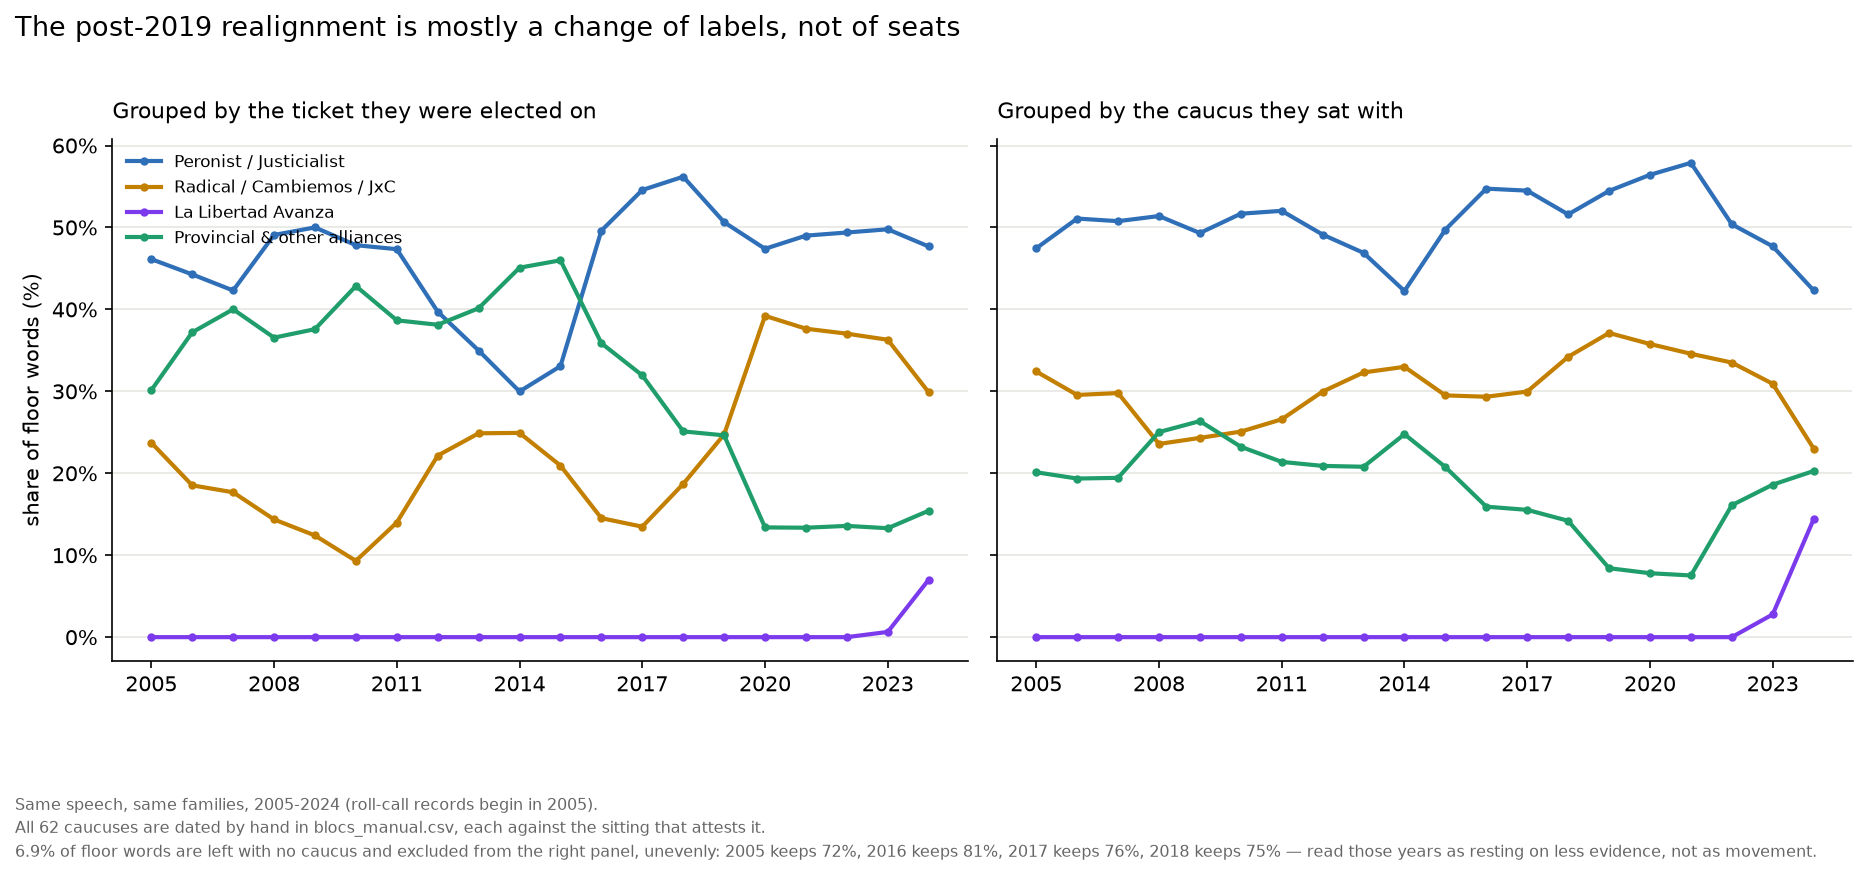

provincial & other, ticket : 30-46% to 2016, 13-15% from 2020
provincial & other, caucus : 16-26% to 2016, 8-20% from 2020


In [4]:
BLOC_SPELLS = ROOT / "reference" / "senado" / "bloque_por_senador_periodo.csv"
spells = pd.read_csv(BLOC_SPELLS)


def namekey(s):
    """Both sides come from the Senate's own data, so the surnames match."""
    return " ".join(deaccent(str(s)).upper().replace(",", " ").split())


by_person = {k: g[["desde", "hasta", "familia"]].values.tolist()
             for k, g in spells.assign(k=spells.senador.map(namekey)).groupby("k")}


GRACE_DAYS = 180  # a sitting this close to a spell belongs to it


def bloc_family(person, date):
    """The family this senator's caucus falls in on that date.

    Just outside a spell the nearest one is carried over, but only within
    GRACE_DAYS. The window matters: the hand-dated correction in blocs_manual.csv
    works by CUTTING spells back to the life of their caucus, and an unbounded
    nearest-match would quietly fill those gaps straight back in and undo it.
    Anything further out — and everyone before 2005 — comes back as NaN and
    drops out rather than being guessed.
    """
    runs = by_person.get(namekey(person))
    if not runs:
        return float("nan")
    for start, end, fam in runs:
        if start <= date <= end:
            return fam
    when = pd.Timestamp(date)
    gap, fam = min((min(abs((pd.Timestamp(r[0]) - when).days),
                        abs((pd.Timestamp(r[1]) - when).days)), r[2]) for r in runs)
    return fam if gap <= GRACE_DAYS else float("nan")


caucus = floor[floor.year >= 2005].copy()
caucus["caucus_family"] = [bloc_family(p, d) for p, d
                           in zip(caucus.person_name, caucus.session_date)]
unplaced = caucus.caucus_family.isna().mean()

# Where the hand-dating cuts a caucus back, the years it vacates have no caucus
# at all — the Senate's records do not say what those senators sat in instead.
# That loss is NOT spread evenly, so it is measured per year and shown: the
# right-hand panel rests on much less evidence in 2016-2018 than in 2012.
coverage = (1 - caucus.assign(gone=caucus.caucus_family.isna())
            .groupby("year").apply(lambda d: d[d.gone].words.sum() / d.words.sum(),
                                   include_groups=False)) * 100
worst = coverage.nsmallest(4).sort_index()


def share(frame, col):
    t = frame.groupby(["year", col]).words.sum().unstack(fill_value=0)
    t = t.reindex(columns=ORDER, fill_value=0)
    return t.div(t.sum(axis=1), axis=0) * 100


panels = [("Grouped by the ticket they were elected on", share(caucus, "family")),
          ("Grouped by the caucus they sat with", share(caucus.dropna(subset=["caucus_family"]),
                                                        "caucus_family"))]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), dpi=150, sharey=True)
for ax, (title, tbl) in zip(axes, panels):
    for col in ORDER:
        ax.plot(tbl.index, tbl[col], color=COLORS[col], linewidth=2.0,
                marker="o", markersize=3, label=col, zorder=2)
    ax.set_title(title, fontsize=10.5, loc="left", pad=10)
    ax.set_xticks(range(2005, 2025, 3))
    ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0].set_ylabel("share of floor words (%)")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(frameon=False, fontsize=8, loc="upper left", ncol=1)
fig.suptitle("The post-2019 realignment is mostly a change of labels, not of seats",
             fontsize=13, x=0.008, ha="left", y=1.02)
fig.text(0.008, -0.20,
         "Same speech, same families, 2005-2024 (roll-call records begin in 2005).\n"
         f"All 62 caucuses are dated by hand in blocs_manual.csv, each against the sitting that attests it.\n"
         f"{unplaced:.1%} of floor words are left with no caucus and excluded from the right panel, unevenly: "
         + ", ".join(f"{y} keeps {v:.0f}%" for y, v in worst.items())
         + " — read those years as resting on less evidence, not as movement.",
         fontsize=7.5, color="#666666", linespacing=1.5)
fig.tight_layout()
fig.savefig(ROOT / "figures" / "ticket_vs_caucus.png", bbox_inches="tight")
plt.show()

print(f"provincial & other, ticket : "
      f"{panels[0][1]['Provincial & other alliances'].loc[2005:2016].min():.0f}"
      f"-{panels[0][1]['Provincial & other alliances'].loc[2005:2016].max():.0f}% to 2016, "
      f"{panels[0][1]['Provincial & other alliances'].loc[2020:].min():.0f}"
      f"-{panels[0][1]['Provincial & other alliances'].loc[2020:].max():.0f}% from 2020")
print(f"provincial & other, caucus : "
      f"{panels[1][1]['Provincial & other alliances'].loc[2005:2016].min():.0f}"
      f"-{panels[1][1]['Provincial & other alliances'].loc[2005:2016].max():.0f}% to 2016, "
      f"{panels[1][1]['Provincial & other alliances'].loc[2020:].min():.0f}"
      f"-{panels[1][1]['Provincial & other alliances'].loc[2020:].max():.0f}% from 2020")

## Fewer sittings, or shorter ones?

A yearly total mixes two different things: how often the chamber sat and
how much was said when it did. Separating them changes the reading of the
2020–2023 fall — and shows that 2020, the remote-procedure year, was
extraordinary in the number of sittings rather than in their length.

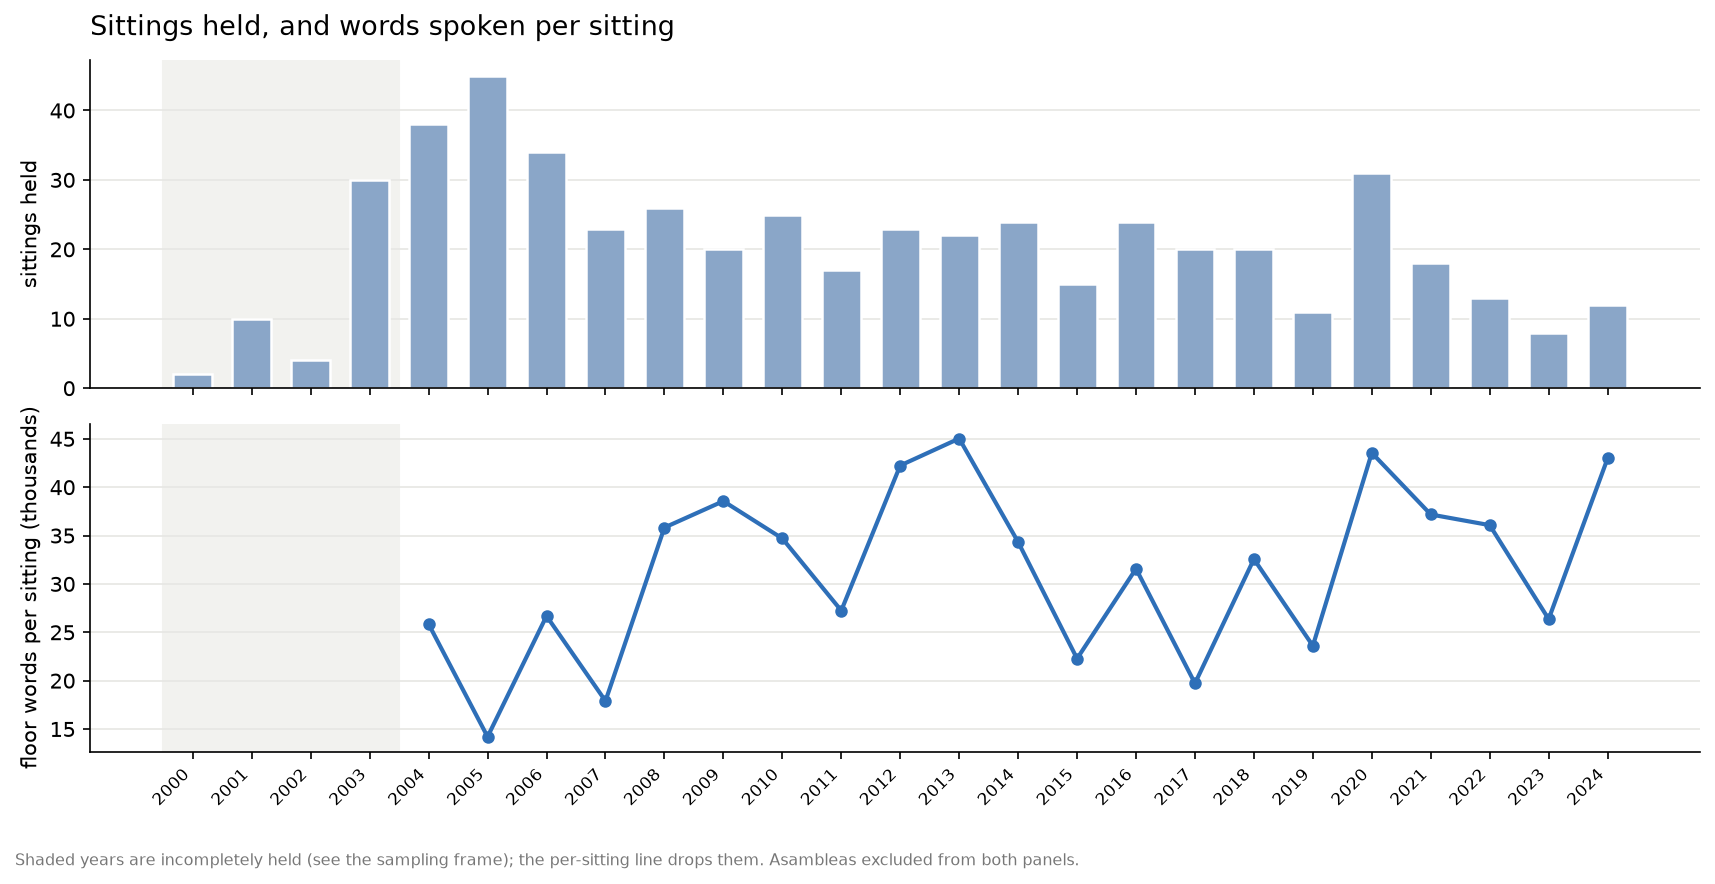

year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
sittings,2.0,10.0,4.0,30.0,38.0,45.0,34.0,23.0,26.0,20.0,...,15.0,24.0,20.0,20.0,11.0,31.0,18.0,13.0,8.0,12.0
words per sitting,806.0,2975.0,3776.0,21892.0,25843.0,14201.0,26684.0,17899.0,35826.0,38560.0,...,22278.0,31568.0,19721.0,32568.0,23600.0,43550.0,37179.0,36076.0,26363.0,42980.0


In [5]:
sessions_held = (corpus[corpus.session_type != "ASAMBLEA"]
                 .groupby("year").session_id.nunique())
words_year = floor.groupby("year").words.sum()
per_session = (words_year / sessions_held).dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11.5, 5.6), dpi=150, sharex=True)
full = [y for y in per_session.index if y not in PARTIAL_YEARS]

ax1.bar(sessions_held.index, sessions_held.values, width=0.66, color="#8AA6C8",
        edgecolor="white", linewidth=1.2)
ax1.set_ylabel("sittings held")
ax1.set_title("Sittings held, and words spoken per sitting", fontsize=13, loc="left", pad=12)

ax2.plot(full, per_session.reindex(full).values / 1000, marker="o", markersize=5,
         linewidth=2, color="#2E6FB8")
ax2.set_ylabel("floor words per sitting (thousands)")
ax2.set_xticks(list(sessions_held.index))
ax2.set_xticklabels(sessions_held.index, rotation=45, ha="right", fontsize=8)

for ax in (ax1, ax2):
    ax.axvspan(min(PARTIAL_YEARS) - 0.5, max(PARTIAL_YEARS) + 0.5, color="#f2f2ef", zorder=0)
    ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.text(0.01, -0.04,
         "Shaded years are incompletely held (see the sampling frame); the per-sitting line drops them. Asambleas excluded from both panels.",
         fontsize=7.5, color="#777777")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "sittings_and_length.png", bbox_inches="tight")
plt.show()

pd.DataFrame({"sittings": sessions_held, "words per sitting": per_session.round(0)}).T

## Chamber temperature

The stenographer events the parser preserves allow something
transcripts-as-text cannot: measuring what happened *around* the words.
Rates are per 10,000 floor words, so a quiet year does not masquerade as a
calm one. The incompletely held years are dropped — a few thousand words
make the denominator too thin to divide by.

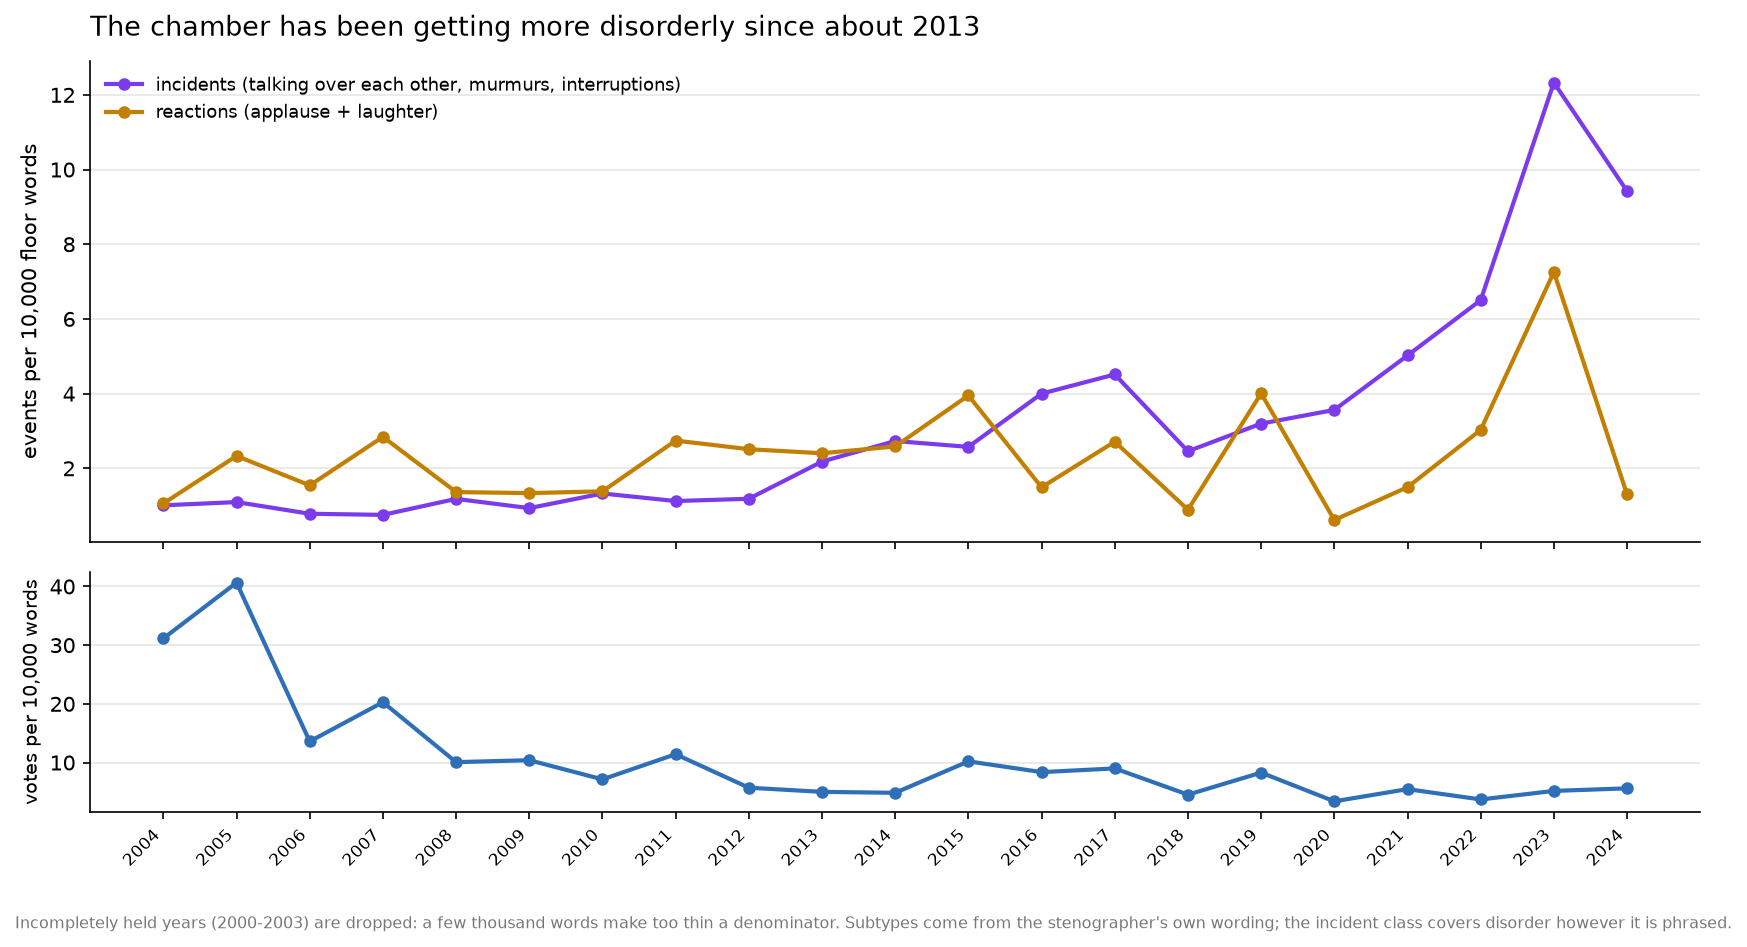

,incidents,reactions,votes
year,,,
2004,1.0,1.1,31.1
2005,1.1,2.3,40.7
2006,0.8,1.5,13.6
2007,0.8,2.8,20.3
2008,1.2,1.4,10.1
2009,0.9,1.3,10.4
2010,1.3,1.4,7.1
2011,1.1,2.7,11.4
2012,1.2,2.5,5.7


In [6]:
events = corpus[(corpus.type == "event") & (corpus.session_type != "ASAMBLEA")]
fw = floor.groupby("year").words.sum()
fw = fw[[y for y in fw.index if y not in PARTIAL_YEARS]]

def rate(subtypes):
    n = events[events.event_type.isin(subtypes)].groupby("year").size()
    return (n / fw * 10_000).reindex(fw.index)

# Votes sit an order of magnitude above the rest and would flatten them on a
# shared axis, so they get their own panel: procedural volume, not temperature.
TEMP = {"incidents (talking over each other, murmurs, interruptions)": (["incident"], "#7C3AED"),
        "reactions (applause + laughter)": (["applause", "laughter"], "#C27F00")}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11.5, 6.0), dpi=150, sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
for name, (subtypes, colour) in TEMP.items():
    r = rate(subtypes)
    ax1.plot(r.index, r.values, marker="o", markersize=5, linewidth=2, color=colour, label=name)
ax1.set_ylabel("events per 10,000 floor words")
ax1.set_title("The chamber has been getting more disorderly since about 2013",
              fontsize=13, loc="left", pad=12)
ax1.legend(frameon=False, fontsize=8.5, loc="upper left")

votes = rate(["vote"])
ax2.plot(votes.index, votes.values, marker="o", markersize=5, linewidth=2, color="#2E6FB8")
ax2.set_ylabel("votes per 10,000 words", fontsize=9)
ax2.set_xticks(list(fw.index))
ax2.set_xticklabels(fw.index, rotation=45, ha="right", fontsize=8)

for ax in (ax1, ax2):
    ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.text(0.01, -0.04,
         "Incompletely held years (2000-2003) are dropped: a few thousand words make too thin a denominator. "
         "Subtypes come from the stenographer's own wording; the incident class covers disorder however it is phrased.",
         fontsize=7.5, color="#777777")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "chamber_temperature.png", bbox_inches="tight")
plt.show()

pd.DataFrame({"incidents": rate(["incident"]), "reactions": rate(["applause", "laughter"]),
              "votes": votes}).round(1)

## Who spoke most, over twenty-five years

In [7]:
span = floor.groupby("person_name").year.agg(["min", "max"])
top = (floor.groupby(["person_name", "province"]).words.sum()
       .sort_values(ascending=False).head(15) / 1000).round(1).rename("floor words (thousands)")
top = top.reset_index().merge(span, left_on="person_name", right_index=True)
top["years on the floor"] = top["min"].astype(str) + "–" + top["max"].astype(str)
top[["person_name", "province", "floor words (thousands)", "years on the floor"]]

,person_name,province,floor words (thousands),years on the floor
0,"MORALES, GERARDO RUBÉN",JUJUY,770.8,2002–2015
1,"PICHETTO, MIGUEL ÁNGEL",RÍO NEGRO,752.9,2001–2019
2,"MAYANS, JOSÉ MIGUEL ÁNGEL",FORMOSA,477.8,2002–2024
3,"NEGRE DE ALONSO, LILIANA TERESITA",SAN LUIS,462.5,2001–2017
4,"PETCOFF NAIDENOFF, LUIS CARLOS",FORMOSA,440.9,2005–2023
5,"SANZ, ERNESTO RICARDO",MENDOZA,405.5,2003–2015
6,"GIUSTINIANI, RUBÉN HÉCTOR",SANTA FE,392.1,2003–2015
7,"RODRÍGUEZ SAÁ, ADOLFO",SAN LUIS,300.9,2005–2023
8,"ESCUDERO, SONIA MARGARITA",SALTA,298.2,2001–2013
9,"CAPITANICH, JORGE MILTON",CHACO,293.6,2003–2007


## Findings

1. **The Peronist/Justicialist family has been the largest on the floor in
   18 of the 21 fully held years.** Its share of floor words runs from 30% to
   56%, median 48%, across four changes of national government. It is never a
   majority and never below three in ten. The three exceptions — 2013, 2014,
   2015, where the residual provincial-and-other bucket is larger — turn out
   to be an artefact of grouping by ticket: regroup the same speech by the
   caucus each senator sat in and the peronist family is the largest in every
   one of the twenty years the caucus data covers.
2. **What moved is mostly the labels everyone ran under, and the caucus
   data now shows it rather than merely warning about it.** By ticket,
   provincial and other alliances hold 30–46% of floor words to 2016 and
   13–15% from 2020, while the radical/Cambiemos family goes the other way
   (9–25% before 2019, 30–39% after) — a chamber that looks realigned at a
   stroke. Group the identical speech by the caucus each senator actually
   sat in and that step disappears: the radical/Cambiemos family sits at
   23–37% throughout, before and after, and provincial and other alliances
   end 2022–2024 at 16–20%, higher than the 13% the ticket view reports.
   Senators did not change sides in 2019; the tickets they had been elected
   on consolidated into two national coalitions. Hand-dating all 62
   caucuses also removed a bump the raw caucus data had invented: the
   peronist share for 2016–2021 fell from 62–64% to 52–58% once the caucuses
   the Senate had carried backwards were cut to the years they actually
   existed. The ticket is still the only affiliation before 2005.
3. **The 2020–2023 collapse was mostly fewer sittings, not quieter ones.**
   Floor words fell 6.4-fold, but that splits into a 3.9-fold fall in
   sittings held (31 to 8, Asambleas excluded) and only a 1.65-fold fall in
   words per sitting. By 2024 a sitting was as long as ever — 43,000 floor
   words, in line with 2013's 45,000 — there were simply twelve of them.
4. **The chamber has been getting steadily more disorderly since about
   2013.** Recorded incidents per 10,000 floor words ran near 1 through the
   2000s, reached 2.2 by 2013, 4.0–4.5 in 2016–2017, 5.0–6.5 in 2021–2022,
   and peaked at 12.3 in 2023 before easing to 9.4 in 2024 — roughly a
   tenfold rise across the span. It begins well before the remote sittings
   of 2020, so it is not an artefact of them.
5. **Floor time follows leadership, not province size.** The most talkative
   senators of the span are bloc chiefs and party leaders — Gerardo Morales
   (Jujuy, 771k words), Miguel Ángel Pichetto (Río Negro, 753k), José
   Mayans (Formosa, 478k) — not the senators of the largest provinces.

**Caveats carried from the sampling frame:** incomplete holdings before
2004, session-type mix, alliance-family grouping (not caucus),
chairs/officers excluded. **Next:** caucus mapping for departed senators,
and the Cámara de Diputados.